# This is the notebook for the project

### Data Cleaning / Combining into DataFrame used in model training

First, we read in the 'labels' - hourly energy demand. Our analysis will focus on the load zone 'COAS', which includes Houston, TX. See the image below for reference (Coast).
 
 
![Img error](https://www.ercot.com/files/assets/2023/04/26/Weather.jpg?)

In [7]:
import pandas as pd

df_demand = pd.read_csv("ercot_demand.csv")
df_demand["period"] = pd.to_datetime(df_demand["period"])
df_demand.head()

,period,COAS,EAST,FWES,NCEN,NRTH,SCEN,SOUT,WEST
0,2023-06-01 00:00:00,17008.0,2373.0,5998.0,20016.0,1692.0,11267.0,5320.0,1712.0
1,2023-06-01 01:00:00,16423.0,2247.0,5964.0,19076.0,1681.0,10901.0,5135.0,1502.0
2,2023-06-01 02:00:00,15935.0,2122.0,5921.0,18104.0,1615.0,10416.0,4956.0,1408.0
3,2023-06-01 03:00:00,15387.0,2025.0,5980.0,17320.0,1550.0,10007.0,4804.0,1352.0
4,2023-06-01 04:00:00,14520.0,1885.0,5876.0,16056.0,1442.0,9321.0,4457.0,1337.0


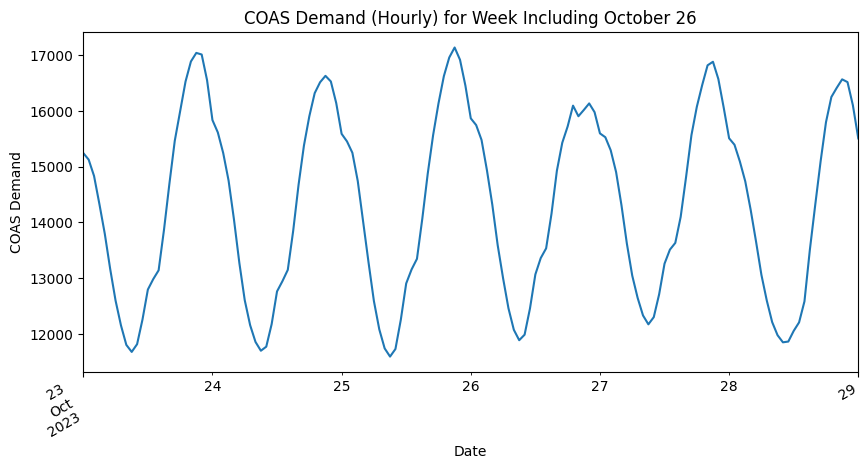

In [26]:
''' Plotting the demand for the week of oct 26, 2024 in COAS'''

df_demand_oct = df_demand[df_demand["period"].dt.month == 10]
# Find the monday-sunday week in October that includes October 26
oct_26 = df_demand_oct[df_demand_oct["period"].dt.day == 26].iloc[0]["period"]
start_of_week = oct_26 - pd.Timedelta(days=oct_26.dayofweek)  # Monday of the week
end_of_week = start_of_week + pd.Timedelta(days=6)  # Sunday of the week
df_demand_week = df_demand_oct[
    (df_demand_oct["period"] >= start_of_week) &
    (df_demand_oct["period"] <= end_of_week)
]
import matplotlib.dates as mdates

ax = df_demand_week.set_index("period")["COAS"].plot(figsize=(10, 5))
ax.set_xlabel("Date")
ax.set_ylabel("COAS Demand")
ax.set_title("COAS Demand (Hourly) for Week Including October 26")
ax.figure.autofmt_xdate()






Importing weather data - see [column descriptions](https://mesonet.agron.iastate.edu/request/download.phtml?network=TX_ASOS)

In [27]:
df_weather = pd.read_csv("asos.csv")

df_weather.head()

,station,valid,lon,lat,tmpf,dwpf,relh,drct,sknt,p01i,...,wxcodes,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth
0,ARM,2023-06-01 00:15,-96.1544,29.2543,70.7,70.7,100.00,90.0,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.7,KARM 010515Z AUTO 09003KT 10SM CLR 22/22 A2989...,NaN
1,AXH,2023-06-01 00:15,-95.4769,29.5061,71.6,70.2,95.35,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.6,KAXH 010515Z AUTO 00000KT 10SM CLR 22/21 A2991...,NaN
2,BYY,2023-06-01 00:15,-95.8634,28.9733,70.3,69.0,95.98,80.0,4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.3,KBYY 010515Z AUTO 08004KT 10SM CLR 21/20 A2988...,NaN
3,MCJ,2023-06-01 00:15,-95.3950,29.7140,75.2,68.0,78.34,150.0,7.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.2,KMCJ 010515Z AUTO 15007KT 10SM FEW041 BKN049 B...,NaN
4,T41,2023-06-01 00:15,-95.0641,29.6692,76.0,69.0,78.93,160.0,5.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.9,KT41 010515Z AUTO 16005KT 10SM CLR 24/21 A2989...,NaN


Importing academic calendar data: resume from [here](https://www.fox26houston.com/news/houston-isd-calendar-for-2023-2024-academic-school-year-updated-released)